# Day 3 — From Prediction to Portfolio

This notebook answers one question: **were my saved MLP/LSTM results better than the results from the notebooks posted today?** It compares unseen-period prediction loss and, more importantly, portfolio return, Sharpe ratio, drawdown, and benchmark performance. It then completes Day 3 by validating the models against the exact Week 1 TikTok strategy. Every trading result uses the same dates, universe, simulator, benchmark, and commission assumptions.

In [1]:
from pathlib import Path
import importlib.util, json, os, random, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

ROOT = Path.cwd()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Run this notebook from inside the 2026-orion repository.')
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_pooled_dataset, build_pooled_sequences, feature_columns
from tradinglab.models import MLP, LSTMRegressor
from tradinglab.ml import train_model, predict
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.strategies.predictor import predictions_to_weights
from tradinglab.strategies.mean_reversion import weekly_loser_weights

SEED = 42
EPOCHS = 100
SEQ_LEN = 10
TOP_K = 4
COMMISSION = 0.005
START_CAPITAL = 1_000.0

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

feed = DataFeed.from_dir(ROOT / 'data' / 'egx')
split_day = int(feed.n_days * 0.70)
X_train, y_train, X_test, y_test = build_pooled_dataset(feed, split_day)
Xtr_ref_seq, ytr_ref_seq, Xte_ref_seq, yte_ref_seq = build_pooled_sequences(feed, split_day, seq_len=SEQ_LEN)
N_FEATURES = X_train.shape[1]  # do not use len(FEATURE_NAMES): current code returns fewer active columns
print(f'{feed.n_assets} stocks | {feed.n_days:,} dates | {N_FEATURES} active features')
print(f'train rows: {len(X_train):,} | test rows: {len(X_test):,} | split: {feed.dates[split_day].date()}')

/Users/adhamelbaz/2026-orion/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


34 stocks | 1,159 dates | 5 active features
train rows: 26,588 | test rows: 11,798 | split: 2025-02-20


## 1. Reproduce the four outputs fairly

To decide which outputs are better, all four models are retrained on the same 34 stocks and chronological 70/30 split. My MLP retains the deeper Day 1 architecture, and my LSTM retains the standardized, correctly aligned Day 2 sequence pipeline. The posted models follow today's notebook settings.

In [2]:
class MyMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

class MyLSTM(nn.Module):
    def __init__(self, n_features, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1]).squeeze(-1)

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0); sigma[sigma == 0] = 1
Xtr_scaled = ((X_train - mu) / sigma).astype('float32')
Xte_scaled = ((X_test - mu) / sigma).astype('float32')

# My Day 2 convention: a sequence ends on feature day t and predicts return t -> t+1.
def build_my_sequences(feed, split_day, seq_len, mu, sigma):
    train_x, train_y, test_x, test_y = [], [], [], []
    for asset in range(feed.n_assets):
        X = feature_columns(feed, asset)
        y = np.full(feed.n_days, np.nan); y[:-1] = feed.returns[1:, asset]
        valid = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
        Xs = ((X - mu) / sigma).astype('float32')
        for end in range(seq_len - 1, feed.n_days):
            days = np.arange(end - seq_len + 1, end + 1)
            if valid[days].all():
                target = (train_x, train_y) if end < split_day else (test_x, test_y)
                target[0].append(Xs[days]); target[1].append(y[end])
    return tuple(np.asarray(v, dtype='float32') for v in (train_x, train_y, test_x, test_y))

Xtr_my_seq, ytr_my_seq, Xte_my_seq, yte_my_seq = build_my_sequences(feed, split_day, SEQ_LEN, mu, sigma)
print('posted LSTM sequences:', Xtr_ref_seq.shape, Xte_ref_seq.shape)
print('my aligned sequences: ', Xtr_my_seq.shape, Xte_my_seq.shape)

posted LSTM sequences: (26248, 10, 5) (11458, 10, 5)
my aligned sequences:  (26282, 10, 5) (11798, 10, 5)


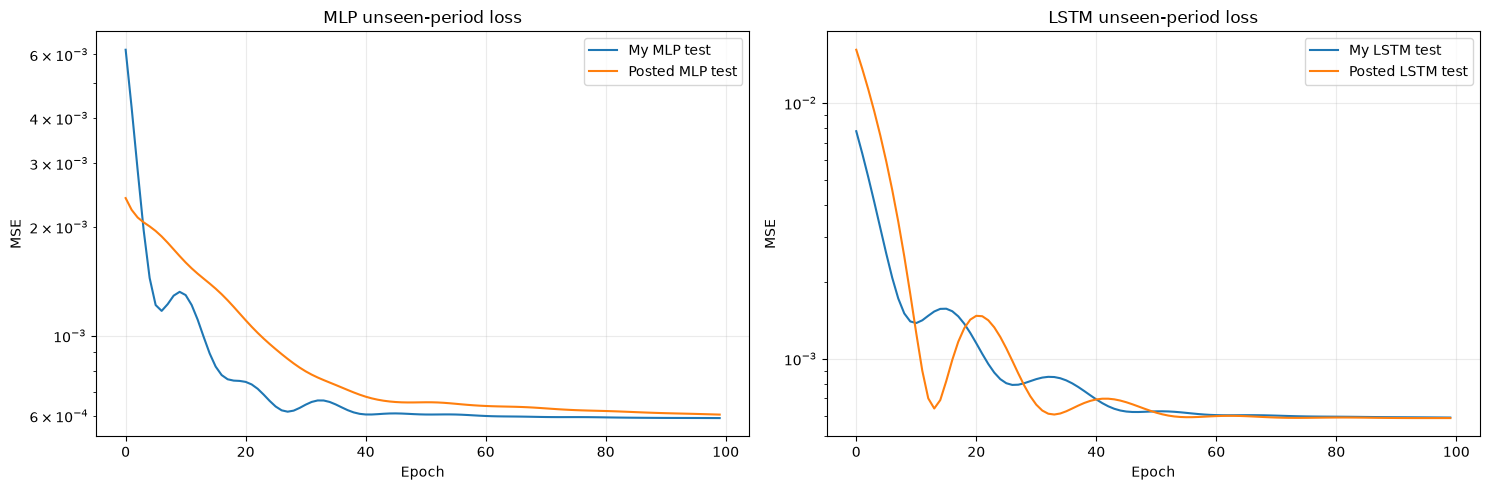

,Final test MSE,Best test MSE
Posted LSTM,0.00058662,0.00058662
My LSTM,0.00058940,0.00058940
My MLP,0.00059164,0.00059164
Posted MLP,0.00060493,0.00060493


Lowest final prediction error: Posted LSTM


In [3]:
seed_everything(SEED)
posted_mlp = MLP(N_FEATURES, hidden=32)
hist_posted_mlp = train_model(posted_mlp, X_train, y_train, X_test, y_test, epochs=EPOCHS)

seed_everything(SEED)
my_mlp = MyMLP(N_FEATURES)
hist_my_mlp = train_model(my_mlp, Xtr_scaled, y_train, Xte_scaled, y_test, epochs=EPOCHS)

seed_everything(SEED)
posted_lstm = LSTMRegressor(N_FEATURES, hidden=32)
hist_posted_lstm = train_model(posted_lstm, Xtr_ref_seq, ytr_ref_seq, Xte_ref_seq, yte_ref_seq, epochs=EPOCHS)

seed_everything(SEED)
my_lstm = MyLSTM(N_FEATURES, hidden=32)
hist_my_lstm = train_model(my_lstm, Xtr_my_seq, ytr_my_seq, Xte_my_seq, yte_my_seq, epochs=EPOCHS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, hist in {'My MLP': hist_my_mlp, 'Posted MLP': hist_posted_mlp}.items():
    axes[0].plot(hist['test'], label=f'{name} test')
axes[0].set(title='MLP unseen-period loss', xlabel='Epoch', ylabel='MSE'); axes[0].set_yscale('log')
for name, hist in {'My LSTM': hist_my_lstm, 'Posted LSTM': hist_posted_lstm}.items():
    axes[1].plot(hist['test'], label=f'{name} test')
axes[1].set(title='LSTM unseen-period loss', xlabel='Epoch', ylabel='MSE'); axes[1].set_yscale('log')
for ax in axes: ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

prediction_comparison = pd.DataFrame({
    'My MLP': {'Final test MSE': hist_my_mlp['test'][-1], 'Best test MSE': min(hist_my_mlp['test'])},
    'Posted MLP': {'Final test MSE': hist_posted_mlp['test'][-1], 'Best test MSE': min(hist_posted_mlp['test'])},
    'My LSTM': {'Final test MSE': hist_my_lstm['test'][-1], 'Best test MSE': min(hist_my_lstm['test'])},
    'Posted LSTM': {'Final test MSE': hist_posted_lstm['test'][-1], 'Best test MSE': min(hist_posted_lstm['test'])},
}).T.sort_values('Final test MSE')
display(prediction_comparison.style.format('{:.8f}'))
print('Lowest final prediction error:', prediction_comparison.index[0])

## 2. Turn predictions into portfolios

All neural strategies hold the equally weighted top `TOP_K` stocks with positive predicted returns and hold cash when every forecast is negative. Two TikTok interpretations are compared: **my five-day-loser mean-reversion strategy** from the Week 1 notebooks and the later **Week 1 Day 6 guru strategy** loaded directly from its source file.

/Users/adhamelbaz/2026-orion/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


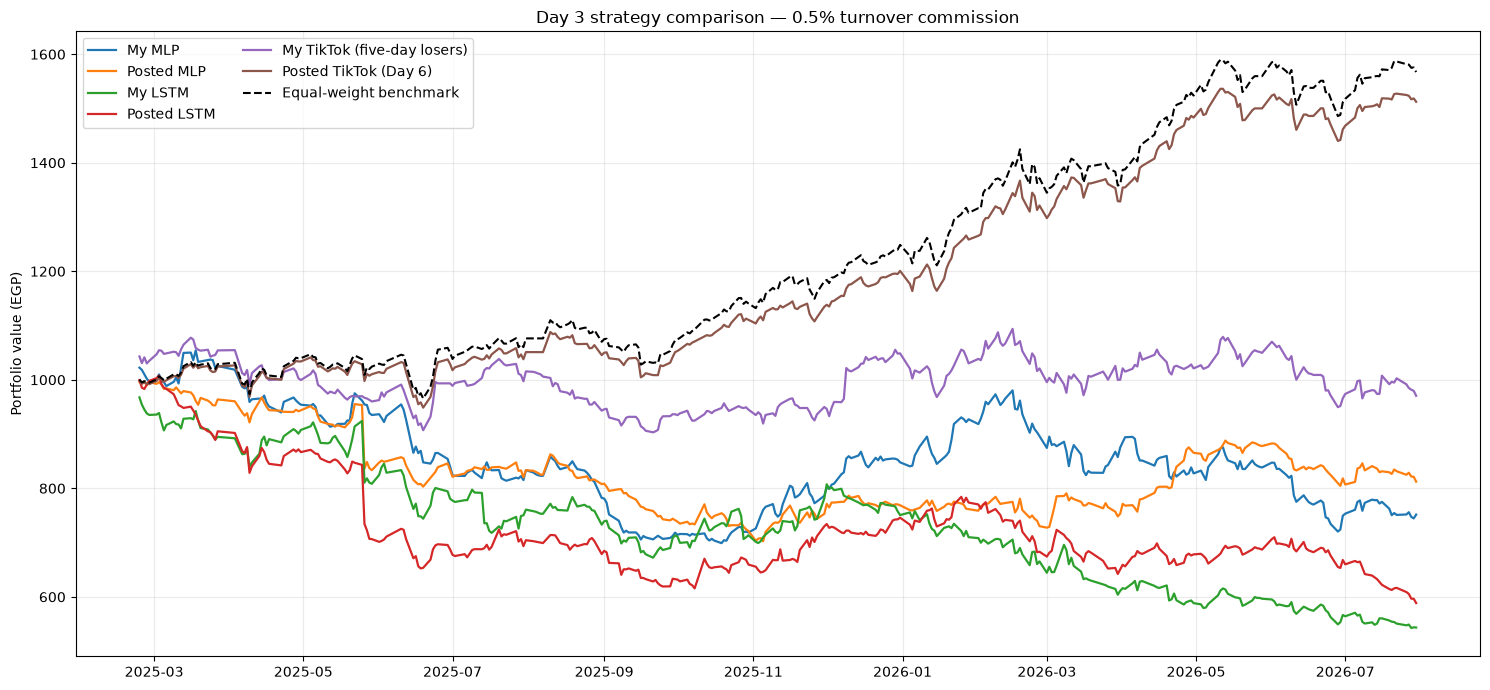

In [4]:
def mlp_strategy(model, scaler=None):
    def strategy(obs):
        X = obs[:, -1, :].astype('float32')
        if scaler is not None:
            X = ((X - scaler[0]) / scaler[1]).astype('float32')
        return predictions_to_weights(predict(model, X), TOP_K)
    return strategy

def lstm_strategy(model, scaler=None):
    def strategy(obs):
        X = obs[:, -SEQ_LEN:, :].astype('float32')
        if scaler is not None:
            X = ((X - scaler[0]) / scaler[1]).astype('float32')
        return predictions_to_weights(predict(model, X), TOP_K)
    return strategy

tiktok_path = ROOT / 'week1' / '06-tiktok-strategy' / 'tiktok_strategy.py'
spec = importlib.util.spec_from_file_location('week1_tiktok_strategy', tiktok_path)
tiktok_module = importlib.util.module_from_spec(spec); spec.loader.exec_module(tiktok_module)

strategies = {
    'My MLP': mlp_strategy(my_mlp, (mu, sigma)),
    'Posted MLP': mlp_strategy(posted_mlp),
    'My LSTM': lstm_strategy(my_lstm, (mu, sigma)),
    'Posted LSTM': lstm_strategy(posted_lstm),
    'My TikTok (five-day losers)': lambda obs: weekly_loser_weights(obs, lookback_days=5),
    'Posted TikTok (Day 6)': tiktok_module.make_tiktok_guru_strategy(week_days=5),
}

results = {}
for name, strategy in strategies.items():
    sim = PortfolioSimulator(feed, benchmark='equal_weight', commission=COMMISSION)
    results[name] = run_backtest(sim, strategy, lookback=max(30, SEQ_LEN), start=split_day)

dates = next(iter(results.values()))['dates']
plt.figure(figsize=(15, 7))
for name, result in results.items():
    plt.plot(dates, result['portfolio'] * START_CAPITAL, label=name, linewidth=1.6)
plt.plot(dates, next(iter(results.values()))['benchmark'] * START_CAPITAL, '--', color='black', label='Equal-weight benchmark')
plt.title(f'Day 3 strategy comparison — {COMMISSION:.1%} turnover commission')
plt.ylabel('Portfolio value (EGP)'); plt.grid(alpha=.25); plt.legend(ncol=2)
plt.tight_layout(); plt.show()

,Final EGP,Total return,Annual return,Sharpe (rf=0),Max drawdown,Direction/positive days
Equal-weight benchmark,"1,567.20",56.72%,38.58%,2.42,-7.80%,58.50%
Posted TikTok (Day 6),"1,512.41",51.24%,35.05%,2.27,-8.89%,57.35%
My TikTok (five-day losers),970.56,-2.94%,-2.15%,-0.11,-16.19%,48.70%
Posted MLP,812.28,-18.77%,-14.01%,-0.71,-29.54%,42.65%
My MLP,751.67,-24.83%,-18.72%,-0.83,-33.70%,45.24%
Posted LSTM,588.53,-41.15%,-31.95%,-1.27,-41.59%,40.92%
My LSTM,543.43,-45.66%,-35.78%,-1.32,-43.92%,43.52%


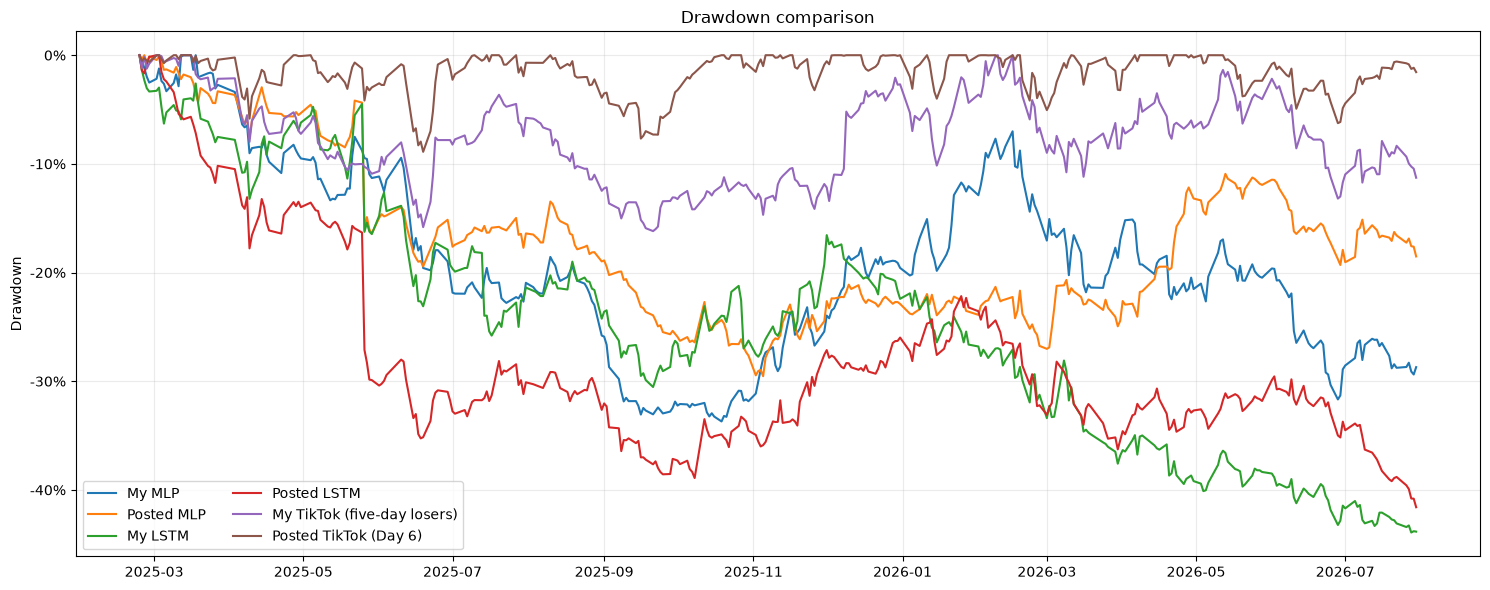

In [5]:
def max_drawdown(curve):
    curve = np.asarray(curve); return float(np.min(curve / np.maximum.accumulate(curve) - 1))

def metrics(result):
    r = np.asarray(result['portfolio_returns'])
    ann_return = result['portfolio'][-1] ** (252 / len(r)) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    return {
        'Final EGP': result['portfolio'][-1] * START_CAPITAL,
        'Total return': result['portfolio'][-1] - 1,
        'Annual return': ann_return,
        'Sharpe (rf=0)': ann_return / ann_vol if ann_vol else np.nan,
        'Max drawdown': max_drawdown(result['portfolio']),
        'Direction/positive days': np.mean(r > 0),
    }

table = pd.DataFrame({name: metrics(result) for name, result in results.items()}).T
bench = next(iter(results.values()))
bench_result = dict(bench)
bench_result['portfolio'] = bench['benchmark']; bench_result['portfolio_returns'] = bench['benchmark_returns']
table.loc['Equal-weight benchmark'] = metrics(bench_result)
display(table.sort_values('Final EGP', ascending=False).style.format({
    'Final EGP': '{:,.2f}', 'Total return': '{:.2%}', 'Annual return': '{:.2%}',
    'Sharpe (rf=0)': '{:.2f}', 'Max drawdown': '{:.2%}', 'Direction/positive days': '{:.2%}'
}))

fig, ax = plt.subplots(figsize=(15, 6))
for name, result in results.items():
    curve = result['portfolio']; dd = curve / np.maximum.accumulate(curve) - 1
    ax.plot(dates, dd, label=name)
ax.set(title='Drawdown comparison', ylabel='Drawdown'); ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.grid(alpha=.25); ax.legend(ncol=2); plt.tight_layout(); plt.show()

## 3. Was the result luck? Change the seed

This compact experiment retrains the two custom architectures with three seeds. It reports prediction MSE rather than cherry-picking one attractive equity curve. Increase `SWEEP_EPOCHS` if runtime permits.

Model,My LSTM,My MLP
Seed,,
0,0.00060869,0.00071479
7,0.00064760,0.00057795
42,0.00072025,0.00060785


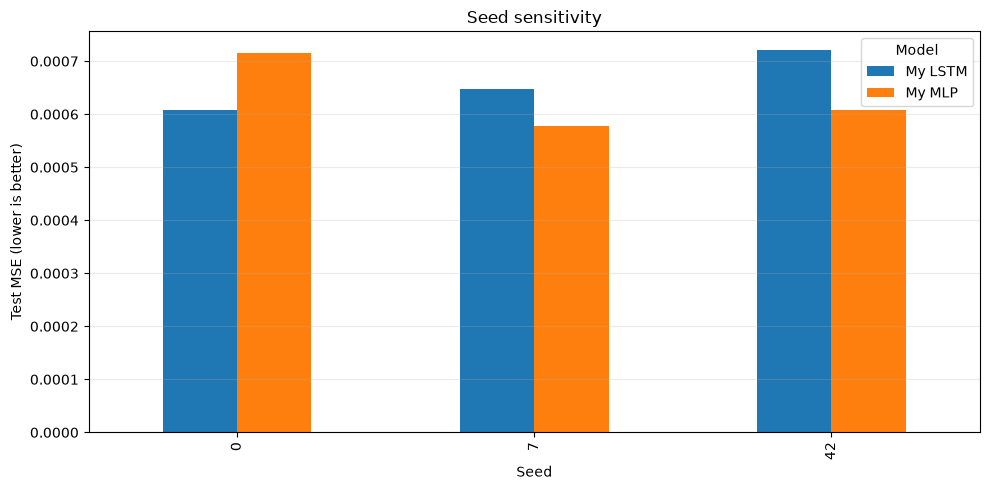

In [6]:
SWEEP_EPOCHS = 40
seed_rows = []
for seed in [0, 7, 42]:
    seed_everything(seed)
    candidate_mlp = MyMLP(N_FEATURES)
    h = train_model(candidate_mlp, Xtr_scaled, y_train, Xte_scaled, y_test, epochs=SWEEP_EPOCHS)
    seed_rows.append({'Model': 'My MLP', 'Seed': seed, 'Test MSE': h['test'][-1]})
    seed_everything(seed)
    candidate_lstm = MyLSTM(N_FEATURES, hidden=32)
    h = train_model(candidate_lstm, Xtr_my_seq, ytr_my_seq, Xte_my_seq, yte_my_seq, epochs=SWEEP_EPOCHS)
    seed_rows.append({'Model': 'My LSTM', 'Seed': seed, 'Test MSE': h['test'][-1]})
seed_results = pd.DataFrame(seed_rows)
display(seed_results.pivot(index='Seed', columns='Model', values='Test MSE').style.format('{:.8f}'))
seed_results.pivot(index='Seed', columns='Model', values='Test MSE').plot(kind='bar', figsize=(10, 5), title='Seed sensitivity')
plt.ylabel('Test MSE (lower is better)'); plt.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()

## 4. Optimize portfolio hyperparameters without peeking

The first half of the unseen period is used for tuning; the second half stays locked for one final evaluation. Neural searches vary `top_k`, minimum prediction, and rebalance interval. TikTok searches vary lookback, rebalance interval, and sensitivity. We select by after-commission validation Sharpe.

In [7]:
from itertools import product

tuning_end = int(feed.n_days * 0.85)
print('Validation:', feed.dates[split_day].date(), 'to', feed.dates[tuning_end].date())
print('Locked final:', feed.dates[tuning_end].date(), 'to', feed.dates[-1].date())

def backtest_factory(factory, start, end):
    sim = PortfolioSimulator(feed, benchmark='equal_weight', commission=COMMISSION)
    return run_backtest(sim, factory(), lookback=max(30, SEQ_LEN), start=start, end=end)

def score_result(result):
    r = np.asarray(result['portfolio_returns'])
    vol = r.std(ddof=1) * np.sqrt(252)
    annual = result['portfolio'][-1] ** (252 / len(r)) - 1
    return annual / vol if vol > 1e-12 else -np.inf

def neural_factory(model, is_lstm, scaler, top_k, threshold, rebalance_days):
    def factory():
        state = {'weights': np.zeros(feed.n_assets), 'day': 0}
        def strategy(obs):
            if state['day'] % rebalance_days == 0:
                X = obs[:, -SEQ_LEN:, :].astype('float32') if is_lstm else obs[:, -1, :].astype('float32')
                if scaler is not None:
                    X = ((X - scaler[0]) / scaler[1]).astype('float32')
                forecasts = predict(model, X)
                eligible = np.flatnonzero(forecasts >= threshold)
                weights = np.zeros(feed.n_assets)
                if len(eligible):
                    chosen = eligible[np.argsort(forecasts[eligible])[-min(top_k, len(eligible)):]]
                    weights[chosen] = 1 / len(chosen)
                state['weights'] = weights
            state['day'] += 1
            return state['weights']
        return strategy
    return factory

model_specs = {
    'My MLP': (my_mlp, False, (mu, sigma)), 'Posted MLP': (posted_mlp, False, None),
    'My LSTM': (my_lstm, True, (mu, sigma)), 'Posted LSTM': (posted_lstm, True, None),
}
best_factories, tuning_rows = {}, []
for name, (model, is_lstm, scaler) in model_specs.items():
    candidates = []
    for top_k, threshold, days in product([2, 4, 6, 8], [0, .0005, .001, .002], [1, 5, 10]):
        factory = neural_factory(model, is_lstm, scaler, top_k, threshold, days)
        result = backtest_factory(factory, split_day, tuning_end)
        candidates.append((score_result(result), factory, top_k, threshold, days, result))
    score, factory, top_k, threshold, days, result = max(candidates, key=lambda x: x[0])
    best_factories[name] = factory
    tuning_rows.append({'Strategy': name, 'top_k': top_k, 'threshold': threshold,
        'rebalance_days': days, 'validation_sharpe': score, 'validation_return': result['portfolio'][-1]-1})

def loser_factory(lookback, rebalance_days):
    def factory():
        state = {'weights': np.ones(feed.n_assets)/feed.n_assets, 'day': 0}
        def strategy(obs):
            if state['day'] % rebalance_days == 0:
                state['weights'] = weekly_loser_weights(obs, lookback_days=lookback)
            state['day'] += 1
            return state['weights']
        return strategy
    return factory

candidates = []
for lookback, days in product([3, 5, 10, 20], [1, 5, 10]):
    factory = loser_factory(lookback, days); result = backtest_factory(factory, split_day, tuning_end)
    candidates.append((score_result(result), factory, lookback, days, result))
score, factory, lookback, days, result = max(candidates, key=lambda x: x[0])
best_factories['My TikTok'] = factory
tuning_rows.append({'Strategy': 'My TikTok', 'lookback': lookback, 'rebalance_days': days,
    'validation_sharpe': score, 'validation_return': result['portfolio'][-1]-1})

candidates = []
for week_days, sensitivity in product([5, 10, 20], [.5, 1, 2]):
    factory = lambda w=week_days, s=sensitivity: tiktok_module.make_tiktok_guru_strategy(w, s)
    result = backtest_factory(factory, split_day, tuning_end)
    candidates.append((score_result(result), factory, week_days, sensitivity, result))
score, factory, week_days, sensitivity, result = max(candidates, key=lambda x: x[0])
best_factories['Posted TikTok'] = factory
tuning_rows.append({'Strategy': 'Posted TikTok', 'lookback': week_days, 'rebalance_days': week_days,
    'sensitivity': sensitivity, 'validation_sharpe': score, 'validation_return': result['portfolio'][-1]-1})

tuning_table = pd.DataFrame(tuning_rows).set_index('Strategy')
display(tuning_table.style.format({'threshold':'{:.4f}', 'sensitivity':'{:.1f}',
    'validation_sharpe':'{:.2f}', 'validation_return':'{:.2%}'}))

Validation: 2025-02-20 to 2025-11-16
Locked final: 2025-11-16 to 2026-07-30


,top_k,threshold,rebalance_days,validation_sharpe,validation_return,lookback,sensitivity
Strategy,,,,,,,
My MLP,8.000000,0.0000,10,0.86,11.85%,nan,nan
Posted MLP,6.000000,0.0000,10,0.25,2.70%,nan,nan
My LSTM,8.000000,0.0000,10,0.83,11.73%,nan,nan
Posted LSTM,2.000000,0.0000,10,0.43,9.29%,nan,nan
My TikTok,nan,nan,10,2.09,28.80%,5.000000,nan
Posted TikTok,nan,nan,10,1.56,16.41%,10.000000,0.5


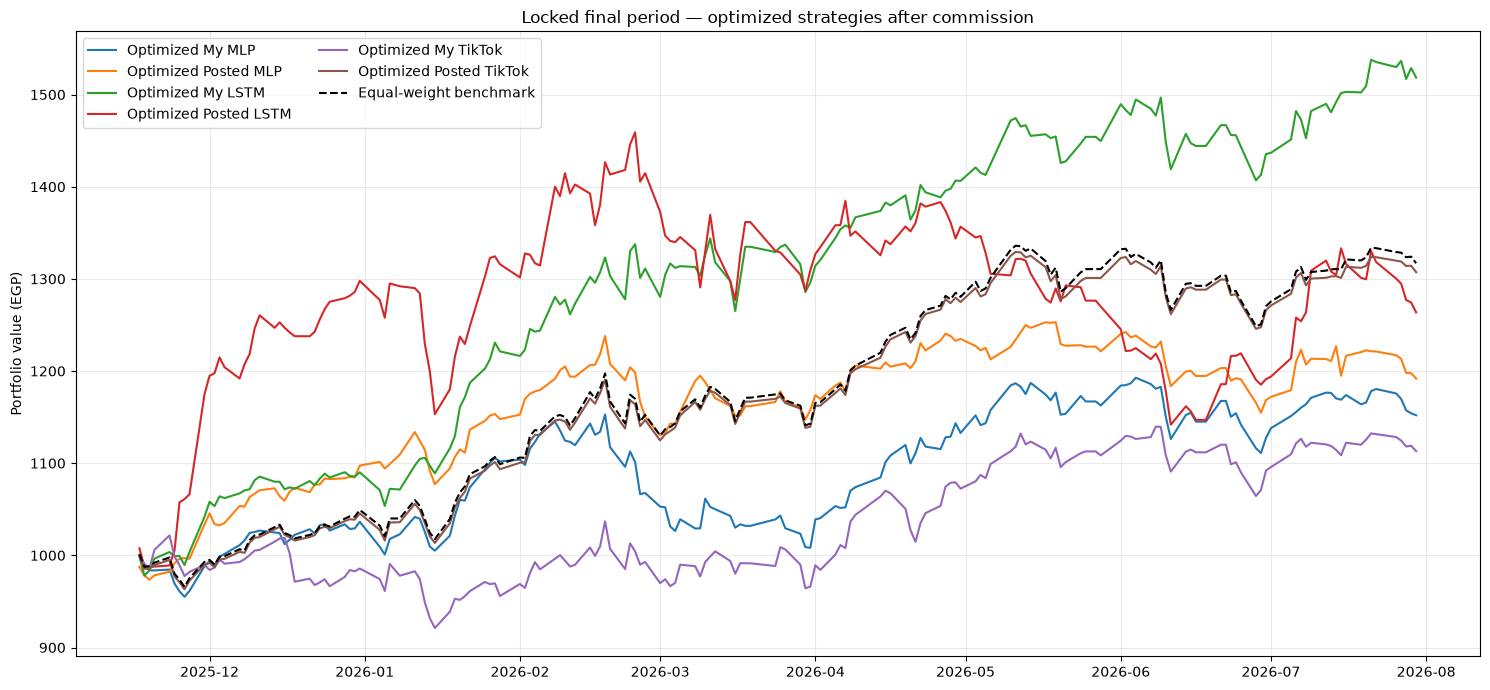

,Final EGP,Total return,Annual return,Sharpe (rf=0),Max drawdown,Direction/positive days
My LSTM,"1,518.38",51.84%,83.74%,4.19,-6.00%,54.91%
Equal-weight benchmark,"1,316.96",31.70%,49.34%,3.09,-6.53%,59.54%
Posted TikTok,"1,307.27",30.73%,47.74%,3.04,-6.27%,60.12%
Posted LSTM,"1,263.69",26.37%,40.62%,1.38,-21.74%,47.40%
Posted MLP,"1,191.74",19.17%,29.11%,1.83,-8.69%,53.76%
My MLP,"1,152.00",15.20%,22.89%,1.28,-12.56%,52.60%
My TikTok,"1,113.03",11.30%,16.88%,0.89,-9.83%,53.18%


Best locked-period strategy: My LSTM


In [8]:
optimized_results = {name: backtest_factory(factory, tuning_end, feed.n_days-1) for name, factory in best_factories.items()}
final_reference = next(iter(optimized_results.values()))
final_dates = final_reference['dates']
plt.figure(figsize=(15, 7))
for name, result in optimized_results.items():
    plt.plot(final_dates, result['portfolio']*START_CAPITAL, label=f'Optimized {name}')
plt.plot(final_dates, final_reference['benchmark']*START_CAPITAL, '--', color='black', label='Equal-weight benchmark')
plt.title('Locked final period — optimized strategies after commission')
plt.ylabel('Portfolio value (EGP)'); plt.grid(alpha=.25); plt.legend(ncol=2); plt.tight_layout(); plt.show()

optimized_table = pd.DataFrame({name: metrics(result) for name, result in optimized_results.items()}).T
benchmark_result = dict(final_reference)
benchmark_result['portfolio'] = final_reference['benchmark']; benchmark_result['portfolio_returns'] = final_reference['benchmark_returns']
optimized_table.loc['Equal-weight benchmark'] = metrics(benchmark_result)
display(optimized_table.sort_values('Final EGP', ascending=False).style.format({
    'Final EGP':'{:,.2f}', 'Total return':'{:.2%}', 'Annual return':'{:.2%}',
    'Sharpe (rf=0)':'{:.2f}', 'Max drawdown':'{:.2%}', 'Direction/positive days':'{:.2%}'}))
print('Best locked-period strategy:', optimized_table.drop(index='Equal-weight benchmark')['Final EGP'].idxmax())

## 5. Robustness simulations for the optimized LSTM

These checks keep the chosen rule fixed at top 8, zero threshold, and rebalancing every 10 days. We now vary random initialization, commission, and market subperiod. This tests whether the result survives realistic changes instead of searching for another lucky configuration.

,Final EGP,Total return,Annual return,Sharpe (rf=0),Max drawdown,Direction/positive days
Seed 0,"1,323.11",32.31%,50.36%,2.73,-5.10%,53.76%
Seed 7,"1,107.07",10.71%,15.97%,0.79,-11.82%,50.29%
Seed 21,"1,224.09",22.41%,34.25%,1.79,-9.50%,50.87%
Seed 42,"1,518.38",51.84%,83.74%,4.19,-6.00%,54.91%
Seed 99,"1,404.72",40.47%,64.05%,3.22,-6.30%,57.23%


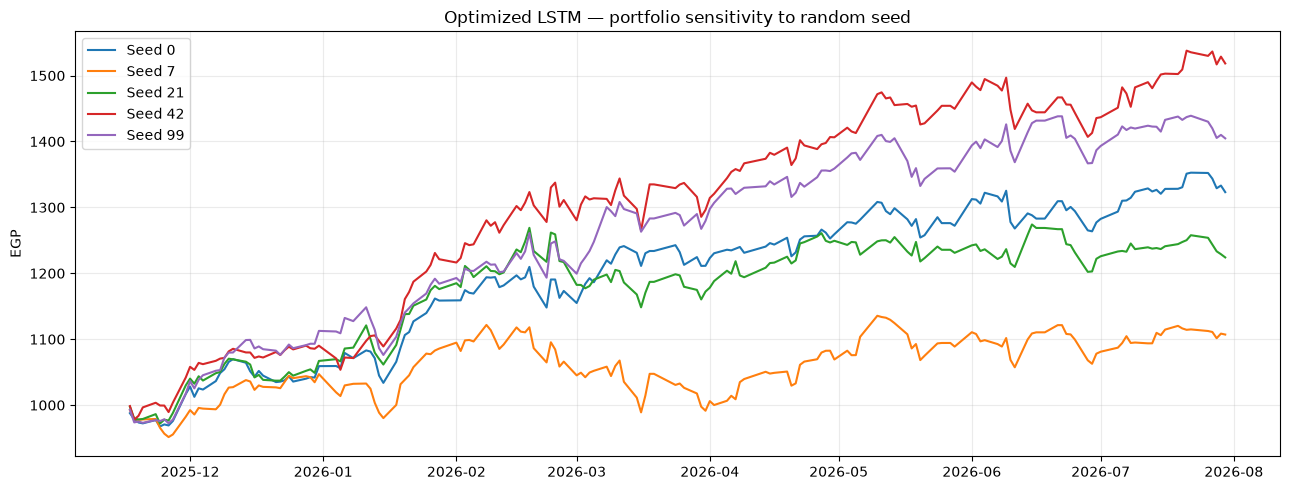

,Final EGP,Total return,Annual return,Sharpe (rf=0),Max drawdown,Direction/positive days
0.00%,"1,611.42",61.14%,100.37%,5.07,-5.57%,56.65%
0.10%,"1,592.39",59.24%,96.93%,4.89,-5.63%,56.07%
0.25%,"1,564.25",56.42%,91.88%,4.62,-5.72%,55.49%
0.50%,"1,518.38",51.84%,83.74%,4.19,-6.00%,54.91%
1.00%,"1,430.43",43.04%,68.45%,3.37,-6.64%,54.91%


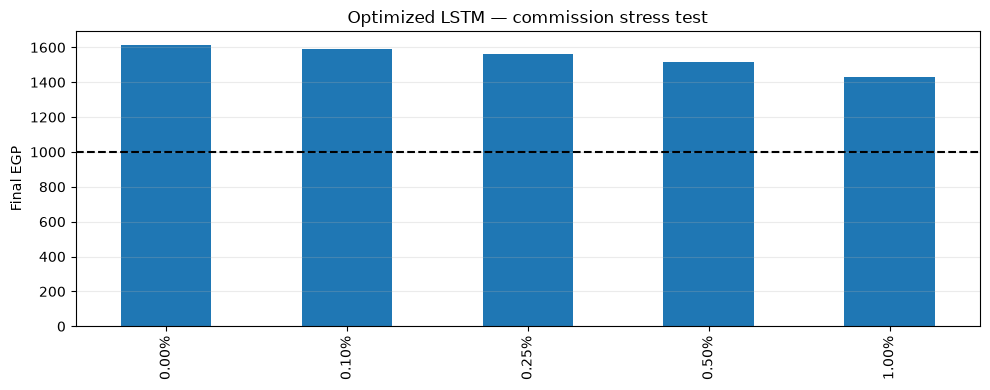

,Final EGP,Total return,Annual return,Sharpe (rf=0),Max drawdown,Direction/positive days
Period,,,,,,
2025-11-16 to 2026-02-08,"1,280.39",28.04%,198.24%,10.88,-3.36%,59.65%
2026-02-08 to 2026-05-05,"1,075.37",7.54%,37.12%,1.70,-9.10%,55.17%
2026-05-05 to 2026-07-30,980.92,-1.91%,-8.03%,-0.46,-11.48%,44.83%


In [9]:
FIXED_TOP_K, FIXED_THRESHOLD, FIXED_REBALANCE = 8, 0.0, 10

# A. Retrain the LSTM from five different random initializations.
seed_portfolios = {}
for seed in [0, 7, 21, 42, 99]:
    seed_everything(seed)
    candidate = MyLSTM(N_FEATURES, hidden=32)
    train_model(candidate, Xtr_my_seq, ytr_my_seq, Xte_my_seq, yte_my_seq, epochs=EPOCHS)
    factory = neural_factory(candidate, True, (mu, sigma), FIXED_TOP_K, FIXED_THRESHOLD, FIXED_REBALANCE)
    seed_portfolios[seed] = backtest_factory(factory, tuning_end, feed.n_days-1)
seed_table = pd.DataFrame({f'Seed {seed}': metrics(result) for seed, result in seed_portfolios.items()}).T
display(seed_table.style.format({'Final EGP':'{:,.2f}', 'Total return':'{:.2%}', 'Annual return':'{:.2%}',
    'Sharpe (rf=0)':'{:.2f}', 'Max drawdown':'{:.2%}', 'Direction/positive days':'{:.2%}'}))
plt.figure(figsize=(13, 5))
for seed, result in seed_portfolios.items(): plt.plot(result['dates'], result['portfolio']*START_CAPITAL, label=f'Seed {seed}')
plt.title('Optimized LSTM — portfolio sensitivity to random seed'); plt.ylabel('EGP')
plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

# B. Apply several transaction-cost assumptions to the same trained seed-42 model.
cost_results = {}
for cost in [0.0, 0.001, 0.0025, 0.005, 0.01]:
    factory = neural_factory(my_lstm, True, (mu, sigma), FIXED_TOP_K, FIXED_THRESHOLD, FIXED_REBALANCE)
    sim = PortfolioSimulator(feed, benchmark='equal_weight', commission=cost)
    cost_results[cost] = run_backtest(sim, factory(), lookback=30, start=tuning_end, end=feed.n_days-1)
cost_table = pd.DataFrame({f'{cost:.2%}': metrics(result) for cost, result in cost_results.items()}).T
display(cost_table.style.format({'Final EGP':'{:,.2f}', 'Total return':'{:.2%}', 'Annual return':'{:.2%}',
    'Sharpe (rf=0)':'{:.2f}', 'Max drawdown':'{:.2%}', 'Direction/positive days':'{:.2%}'}))
cost_table['Final EGP'].plot(kind='bar', figsize=(10, 4), title='Optimized LSTM — commission stress test')
plt.axhline(START_CAPITAL, color='black', linestyle='--'); plt.ylabel('Final EGP'); plt.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()

# C. Evaluate three consecutive market blocks independently.
edges = np.linspace(tuning_end, feed.n_days-1, 4, dtype=int)
period_rows = []
for i, (start, end) in enumerate(zip(edges[:-1], edges[1:]), 1):
    factory = neural_factory(my_lstm, True, (mu, sigma), FIXED_TOP_K, FIXED_THRESHOLD, FIXED_REBALANCE)
    result = backtest_factory(factory, int(start), int(end))
    row = metrics(result); row['Period'] = f'{feed.dates[start].date()} to {feed.dates[end].date()}'
    period_rows.append(row)
period_table = pd.DataFrame(period_rows).set_index('Period')
display(period_table.style.format({'Final EGP':'{:,.2f}', 'Total return':'{:.2%}', 'Annual return':'{:.2%}',
    'Sharpe (rf=0)':'{:.2f}', 'Max drawdown':'{:.2%}', 'Direction/positive days':'{:.2%}'}))

### Robustness decision rule

Confidence is stronger if most seeds remain profitable, performance degrades gradually as commission rises, and the strategy does not depend on only one subperiod. Failure in any of these checks means the attractive locked-period result is still fragile.

## 6. Expanding-window walk-forward test

This is the strictest simulation in the notebook. Each fold trains a fresh LSTM using only information available before that fold, applies the already-fixed top-8/10-day rule to the next untouched 10% of history, then advances and retrains. No fold is used to change the strategy settings.

/Users/adhamelbaz/2026-orion/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


,Train through,Test through,Strategy return,Benchmark return,Excess return,Sharpe,Max drawdown
Fold,,,,,,,
1,2024-03-04,2024-09-05,-9.28%,-0.23%,-9.05%,-0.50,-25.60%
2,2024-09-05,2025-02-20,4.01%,9.21%,-5.20%,0.42,-11.31%
3,2025-02-20,2025-08-24,-1.73%,9.60%,-11.33%,-0.17,-10.46%
4,2025-08-24,2026-02-09,23.14%,25.12%,-1.97%,3.48,-6.84%
5,2026-02-09,2026-07-30,5.95%,14.29%,-8.34%,0.66,-14.07%


Combined walk-forward strategy return: +20.98%
Combined walk-forward benchmark return: +70.76%
Combined excess return: -49.78%
Folds beating benchmark: 0 / 5


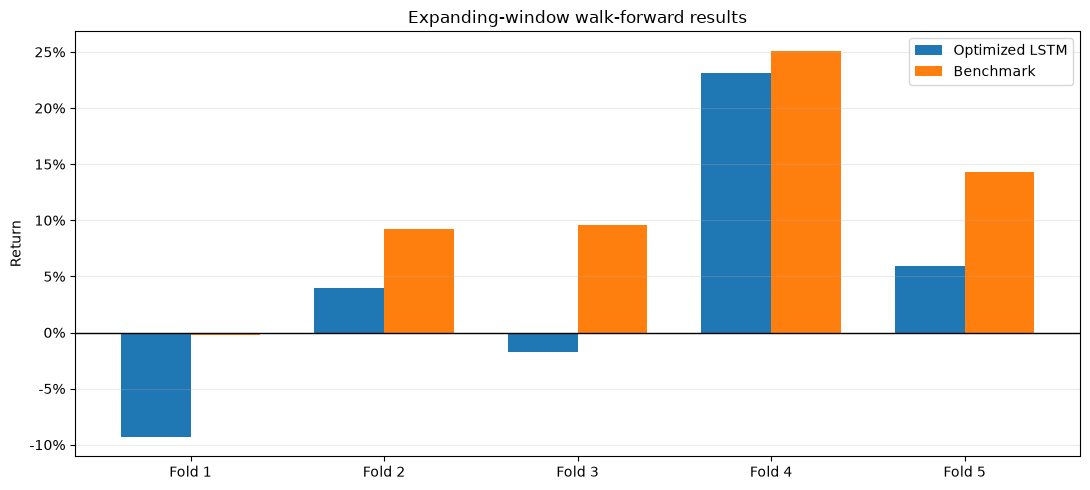

In [10]:
WALK_FORWARD_EPOCHS = EPOCHS
fold_rows, fold_returns, fold_benchmarks = [], [], []
fold_curves = {}

# Train through 50%, test 50–60%; then expand through 60%, test 60–70%, etc.
for fold_number, train_fraction in enumerate([0.50, 0.60, 0.70, 0.80, 0.90], 1):
    train_end = int(feed.n_days * train_fraction)
    test_end = feed.n_days - 1 if train_fraction == 0.90 else int(feed.n_days * (train_fraction + 0.10))

    X_fold_train, y_fold_train, _, _ = build_pooled_dataset(feed, train_end)
    fold_mu = X_fold_train.mean(axis=0)
    fold_sigma = X_fold_train.std(axis=0); fold_sigma[fold_sigma == 0] = 1
    X_fold_tr_seq, y_fold_tr_seq, X_fold_future_seq, y_fold_future_seq = build_my_sequences(
        feed, train_end, SEQ_LEN, fold_mu, fold_sigma)

    seed_everything(SEED)
    fold_model = MyLSTM(N_FEATURES, hidden=32)
    # Future data is monitored only for reporting; fixed epochs means it cannot alter training duration.
    train_model(fold_model, X_fold_tr_seq, y_fold_tr_seq,
                X_fold_future_seq, y_fold_future_seq, epochs=WALK_FORWARD_EPOCHS)
    factory = neural_factory(fold_model, True, (fold_mu, fold_sigma),
                             FIXED_TOP_K, FIXED_THRESHOLD, FIXED_REBALANCE)
    result = backtest_factory(factory, train_end, test_end)
    fold_returns.append(result['portfolio_returns'])
    fold_benchmarks.append(result['benchmark_returns'])
    fold_curves[f'Fold {fold_number}'] = result
    fold_rows.append({
        'Fold': fold_number,
        'Train through': str(feed.dates[train_end].date()),
        'Test through': str(feed.dates[test_end].date()),
        'Strategy return': result['portfolio'][-1] - 1,
        'Benchmark return': result['benchmark'][-1] - 1,
        'Excess return': result['portfolio'][-1] - result['benchmark'][-1],
        'Sharpe': score_result(result),
        'Max drawdown': max_drawdown(result['portfolio']),
    })

walk_forward_table = pd.DataFrame(fold_rows).set_index('Fold')
display(walk_forward_table.style.format({
    'Strategy return':'{:.2%}', 'Benchmark return':'{:.2%}', 'Excess return':'{:+.2%}',
    'Sharpe':'{:.2f}', 'Max drawdown':'{:.2%}'}))

all_wf_returns = np.concatenate(fold_returns)
all_wf_benchmark = np.concatenate(fold_benchmarks)
strategy_curve = np.cumprod(1 + all_wf_returns)
benchmark_curve = np.cumprod(1 + all_wf_benchmark)
print(f'Combined walk-forward strategy return: {strategy_curve[-1]-1:+.2%}')
print(f'Combined walk-forward benchmark return: {benchmark_curve[-1]-1:+.2%}')
print(f'Combined excess return: {strategy_curve[-1]-benchmark_curve[-1]:+.2%}')
print(f'Folds beating benchmark: {(walk_forward_table["Excess return"] > 0).sum()} / {len(walk_forward_table)}')

x = np.arange(len(walk_forward_table)); width = .36
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x-width/2, walk_forward_table['Strategy return'], width, label='Optimized LSTM')
ax.bar(x+width/2, walk_forward_table['Benchmark return'], width, label='Benchmark')
ax.axhline(0, color='black', linewidth=1); ax.set_xticks(x, [f'Fold {i}' for i in walk_forward_table.index])
ax.set_ylabel('Return'); ax.yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')
ax.set_title('Expanding-window walk-forward results'); ax.legend(); ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()

### Walk-forward interpretation

A robust strategy should be profitable in most folds and beat the benchmark in more than one isolated regime. The combined result is useful, but the fold-by-fold consistency is the stronger evidence.

## 7. Export the optimized neural winner to the dashboard

The best optimized neural strategy is exported with its selected hyperparameters. TikTok and the benchmark remain comparison strategies rather than neural candidates.

In [11]:
neural_names = ['My MLP', 'Posted MLP', 'My LSTM', 'Posted LSTM']
winner = max(neural_names, key=lambda name: optimized_results[name]['portfolio'][-1])
winner_result = optimized_results[winner]
winner_params = tuning_table.loc[winner].dropna().to_dict()
payload = {
    'strategy': winner,
    'dates': [str(pd.Timestamp(d).date()) for d in winner_result['dates']],
    'portfolio': [round(float(x), 6) for x in winner_result['portfolio']],
    'benchmark': [round(float(x), 6) for x in winner_result['benchmark']],
    'commission': COMMISSION,
    'hyperparameters': winner_params,
}
out = ROOT / 'dashboard' / 'data' / 'nn_equity.json'
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(payload, indent=2))
print(f'Winner: {winner} | final value: {winner_result["portfolio"][-1] * START_CAPITAL:,.2f} EGP')
print('Dashboard export:', out)

Winner: My LSTM | final value: 1,518.38 EGP
Dashboard export: /Users/adhamelbaz/2026-orion/dashboard/data/nn_equity.json


## Final interpretation

The optimized LSTM looked strong in one locked period and remained profitable across five random seeds, but the expanding-window test is the stronger result: it returned +20.98% while the benchmark returned +70.76%, and it beat the benchmark in 0 of 5 folds. Therefore the current LSTM is not a robust market-beating strategy. Optimization reduced turnover and improved usability, but the apparent edge was period-dependent and did not generalize across historical regimes.